## バージョン情報
### V0.4

```
id : id
health_condition : 健康状態  (y)

==========================================

1  sleep_duration : 睡眠時間
2  heart_rate : 心拍数
3  bmi : BMI
4  calorie_expenditure :  カロリー消費量
5  step_count : ステップ数
6  exercise_duration : 運動時間
7  water_intake : 水分摂取量
9  stress_level : ストレスレベル
10 sleep_quality : 睡眠の質
11 physical_activity_level : 身体活動レベル

==========================================
追加

16 healthy_score : 健康スコア
17 unhealthy_score : 不健康スコア
18 stress_per_sleep : ストレス係数:  ストレスレベル/睡眠時間

==========================================
削除
14 short_sleep_flag : 睡眠時間が6時間未満なら「1」、そうでない（空白も含む）なら「0」
8  diet_type : 食事タイプ
13 gender : 性別
12 smoking_alcohol : 喫煙・飲酒
15 exercise_strength : 運動の強度

```



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

In [8]:
def df_Data_Cleansing(df):
    cat_cols = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    #14 
    #df['short_sleep_flag'] = (df['sleep_duration'] < 6.0).astype(int)

    #15 
    #df["exercise_strength"] = df['calorie_expenditure'] / ((df['exercise_duration'] + 0.1) * df['bmi'])
            
           
    
    #16
    df['healthy_score'] = (
        df['sleep_duration'].between(7, 8).astype(int) +
        (df['bmi'] <= 19).astype(int) +
        (df['exercise_duration'] >= 40).astype(int) +
        (df['stress_level'] == 'low').astype(int) +
        (df['sleep_quality'] == 'good').astype(int) +
        (df['physical_activity_level'] == 'active').astype(int)
    )
    
    #17
    df['unhealthy_score'] = (
        df['sleep_duration'].between(5, 6).astype(int) +
        (df['bmi'] >= 27).astype(int) +
        (df['calorie_expenditure'] <= 1400).astype(int) +
        (df['step_count'] <= 5000).astype(int) +
        (df['exercise_duration'] <= 30).astype(int) +
        (df['stress_level'] == 'High').astype(int) +
        (df['sleep_quality'].astype(str).str.strip() == 'poor').astype(int) + 
        df['physical_activity_level'].isin(['sedentary', 'moderate']).astype(int) +
        (df['smoking_alcohol'] == 'yes').astype(int)
    )
    #18
    stress_mapping = {'low': 1, 'medium': 2, 'high': 3}
    df['stress_level_num'] = df['stress_level'].map(stress_mapping).astype(float)
    df['stress_per_sleep'] = df['stress_level_num'] / df['sleep_duration']

    # 不要な特徴量をまとめて削除
    drop_cols = [
        'stress_level_num',  # 計算用の一時データ（重複）
        'diet_type',
        'gender',
        'smoking_alcohol',
    ]
    df = df.drop(columns=drop_cols, errors='ignore')    
                
    return df

In [9]:
#読み込み
df = df_Data_Cleansing(pd.read_csv('data/train.csv',encoding="utf-8")) 
df_test = df_Data_Cleansing(pd.read_csv('data/test.csv',encoding="utf-8"))

In [10]:
df

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,healthy_score,unhealthy_score,stress_per_sleep
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,high,average,sedentary,0,5,0.574713
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,low,average,moderate,2,3,0.180832
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,high,poor,active,1,3,0.567108
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,high,average,active,2,0,0.638298
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,NaN,average,sedentary,2,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,high,poor,active,1,2,0.475436
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,medium,average,moderate,1,2,0.346021
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,NaN,average,active,3,0,NaN
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,NaN,average,active,3,1,NaN


In [11]:
df_test

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,healthy_score,unhealthy_score,stress_per_sleep
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,high,poor,active,2,2,0.560748
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,high,poor,sedentary,0,4,NaN
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,medium,poor,active,2,1,0.299401
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,low,good,moderate,4,2,0.140252
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,high,average,active,1,1,0.546448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295748,985836,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,low,average,active,4,0,0.140252
295749,985837,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,NaN,average,moderate,0,4,NaN
295750,985838,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,high,average,sedentary,0,2,NaN
295751,985839,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,high,poor,moderate,1,4,0.413793


In [12]:
#特徴量(X)とターゲット(y)の分割
X = df.drop(['id', 'health_condition'], axis=1)
y = df['health_condition']

#ターゲット(y)を数値に変換
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#学習
model = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
model.fit(X, y_encoded)

#予測と提出ファイルの作成
X_test = df_test.drop(['id'], axis=1)
preds = model.predict(X_test)

#予測結果（数値）を元のテキストラベルに戻す
submission_labels = le.inverse_transform(preds)

submission = pd.DataFrame({
    'id': df_test['id'],
    'health_condition': submission_labels
})
submission.to_csv('submission.csv', index=False)
X_test.head(100).to_csv("submit_x_x_x_x_x_x.csv", index=False)

print("""=========================



提出用ファイル 'submission.csv' を作成しました☆

""")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002734 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2067
[LightGBM] [Info] Number of data points in the train set: 690088, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612



提出用ファイル 'submission.csv' を作成しました☆




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2066
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


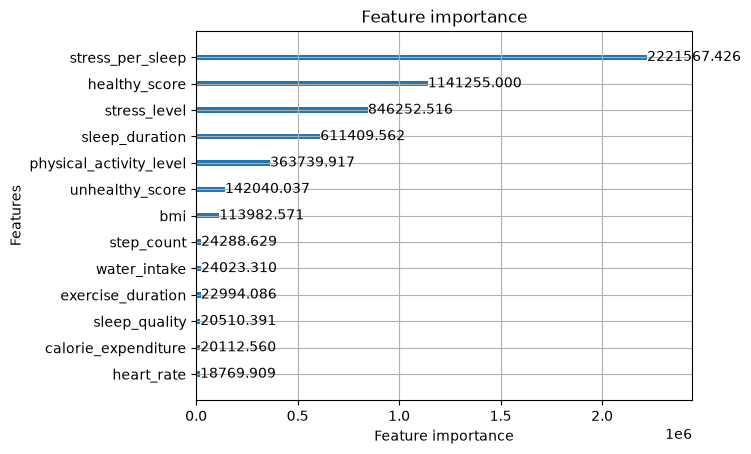


学習用Balanced Accuracy: 0.95032




In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

# 学習データを8:2に分割
X_train, X_valid, y_train, y_valid = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# モデルの学習
model = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.show()

# 手元のデータで予測してスコアを計算
valid_preds = model.predict(X_valid)
score = balanced_accuracy_score(y_valid, valid_preds)

print(f"""=========================

学習用Balanced Accuracy: {score:.5f}

""")